### 1. Collect Initial Data

The first step in data understanding phase is to **collect and load the raw dataset**.  
In this project, the dataset is stored in the `data/raw/titanic.csv` path and contains Titanic passenger information, including survival outcomes and passenger characteristics.  

By loading the dataset, we can:  
- Confirm that the data is accessible and correctly formatted.  
- Preview the first few records to understand the structure and type of information available.  

In [44]:
# Import libraries
import pandas as pd
import numpy as np

from titanic_surv.dataset import load_data

# Load the Titanic dataset
data = load_data("titanic.csv")

# Display basic statistics for numeric columns
data.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


### 2. Describe Data

In this section, the dataset is described using **descriptive statistics** and **data structure inspection**.  
The goal is to understand the distribution, scale, and basic characteristics of each variable before deeper exploration.

Specifically, this step helps to:
- Identify numerical and categorical variables
- Compute summary statistics such as count, mean, standard deviation, minimum, and maximum
- Verify that data types are correctly assigned
- Understand the balance of the target variable (Survived)

#### 2.1 Dataset Structure and Variables

The dataset contains passenger-level records. Each row represents one passenger, and each column represents a passenger attribute or outcome.

In [45]:
# Display column names
data.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [46]:
data.shape

(1309, 28)

#### 2.2 Data Types Inspection

Understanding data types is important because:
- Numerical variables are used for statistical analysis and modeling
- Categorical variables must be encoded before modeling
- Incorrect data types may lead to inaccurate results

In [47]:
# Inspect data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

#### 2.3 Descriptive Statistics

Descriptive statistics summarize the central tendency and spread of numerical variables using:
- Count
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles (25%, 50%, 75%)

In [48]:
# Descriptive statistics for numerical columns
data.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


#### 2.4 Target Variable Identification and Correction

During data inspection, it was observed that the survival outcome column is incorrectly named as **`2urvived`** in the raw dataset.

Based on domain knowledge and dataset context, this column is assumed to represent the passenger survival outcome:
- 0 = Did not survive
- 1 = Survived

To ensure clarity and consistency throughout the analysis, the column is renamed to **`Survived`** before further processing.


In [49]:
# Rename inconsistent or incorrect column names
data = data.rename(columns={
    "Passengerid": "PassengerId",
    "sibsp": "SibSp",
    "2urvived": "Survived"
})

# Verify the fix
data.columns

Index(['PassengerId', 'Age', 'Fare', 'Sex', 'SibSp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', 'Survived'],
      dtype='object')

In [50]:
# Class distribution
data["Survived"].value_counts()

Survived
0    967
1    342
Name: count, dtype: int64

In [51]:
# Percentage distribution
data["Survived"].value_counts(normalize=True) * 100

Survived
0    73.873186
1    26.126814
Name: proportion, dtype: float64

#### 2.5 Summary Statistics Table

Below is a structured summary of key numerical variables relevant to survival prediction:

In [52]:
# Select key numerical columns
key_features = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

data[key_features].describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.261268,2.294882,29.503186,0.498854,0.385027,33.281086
std,0.439494,0.837836,12.905241,1.041658,0.865560,51.741500
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


### 3. Explore Data

In this section, exploratory data analysis (EDA) is performed to uncover patterns, relationships, and trends within the Titanic dataset. The goal is to visually and statistically explore how passenger characteristics relate to survival outcomes.

Exploration focuses on:
- Survival Distribution
- Survival distribution across passenger classes
- Age Distribution by passenger class and survival outcome
- Survival by Family size
- Family Relationships Analysis
- Survival Rate Across Fare Categories

#### 3.1 Survival Distribution
We begin by examining the overall distribution of survival outcomes to understand class balance in the dataset.

***Insight***: 
- About 26% of passengers survived, meaning most passengers did not.
- Standard deviation is = 0.44. Meaning there is some variability, which makes sense for a 0/1 variable.
- The dataset is imbalanced, with significantly more passengers not surviving.
- This imbalance must be considered when interpreting patterns and building predictive models.

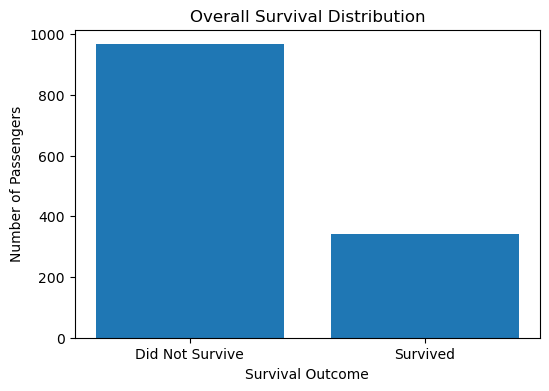

In [107]:
import matplotlib.pyplot as plt
survival_counts = data["Survived"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Did Not Survive", "Survived"], survival_counts.values)
plt.title("Overall Survival Distribution")
plt.ylabel("Number of Passengers")
plt.xlabel("Survival Outcome")
plt.show()


#### 3.2 Survival Distribution Across Passenger Classes
Passenger class is a proxy for socio-economic status. This analysis explores how survival outcomes vary across classes.

***Insight***: 
- First-class passengers show a substantially higher survival count.
- Third-class passengers experienced the lowest survival.
- This aligns with historical accounts of evacuation priority.
- The chart shows that most passengers traveled in 3rd class, suggesting socio-economic imbalance.

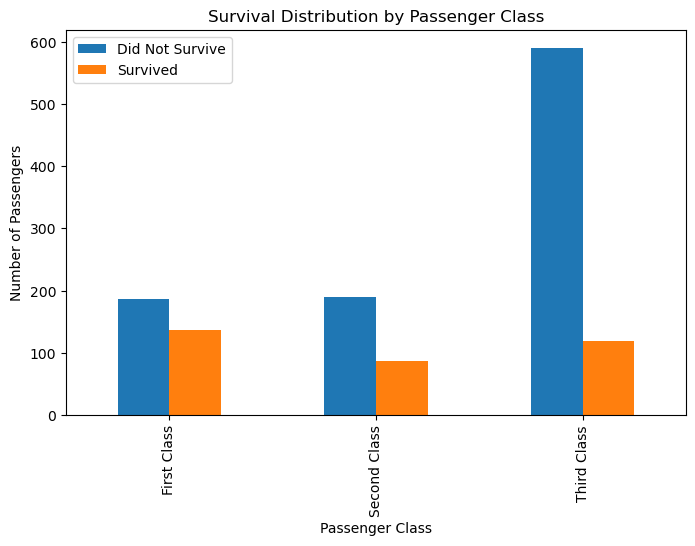

In [57]:
# Map class labels
data_viz = data.copy()
data_viz["Pclass_Label"] = data_viz["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

# Map class labels
data_viz = data.copy()
data_viz["Pclass_Label"] = data_viz["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

class_survival = (
    data_viz
    .groupby(["Pclass_Label", "Survived"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Grouped bar chart
class_survival.plot(kind="bar", figsize=(8, 5))
plt.title("Survival Distribution by Passenger Class")
plt.ylabel("Number of Passengers")
plt.xlabel("Passenger Class")
plt.legend(["Did Not Survive", "Survived"])
plt.show()


#### 3.3 Age Distribution by passenger class and survival outcome
Age is explored to determine whether survival varies across age groups and classes.

***Insight***: 
- The average age is 29.5 years
- The standard deviation is 12.9 which indicate that most passengers’ ages are within 29.5 ± 12.9 years (roughly between 16.6 and 42.4 years)
- The standard deviation is 12.9 indicates that passenger ages are fairly spread out - there are children, adults, and elderly passengers, not just a narrow age group.
- Younger passengers appear more frequently among survivors.
- The dataset includes infants, adults, and elderly passengers. Age may strongly influence survival.
- Adults aged 21-30 experienced catastrophic mortality; this age group represented the bulk of deaths


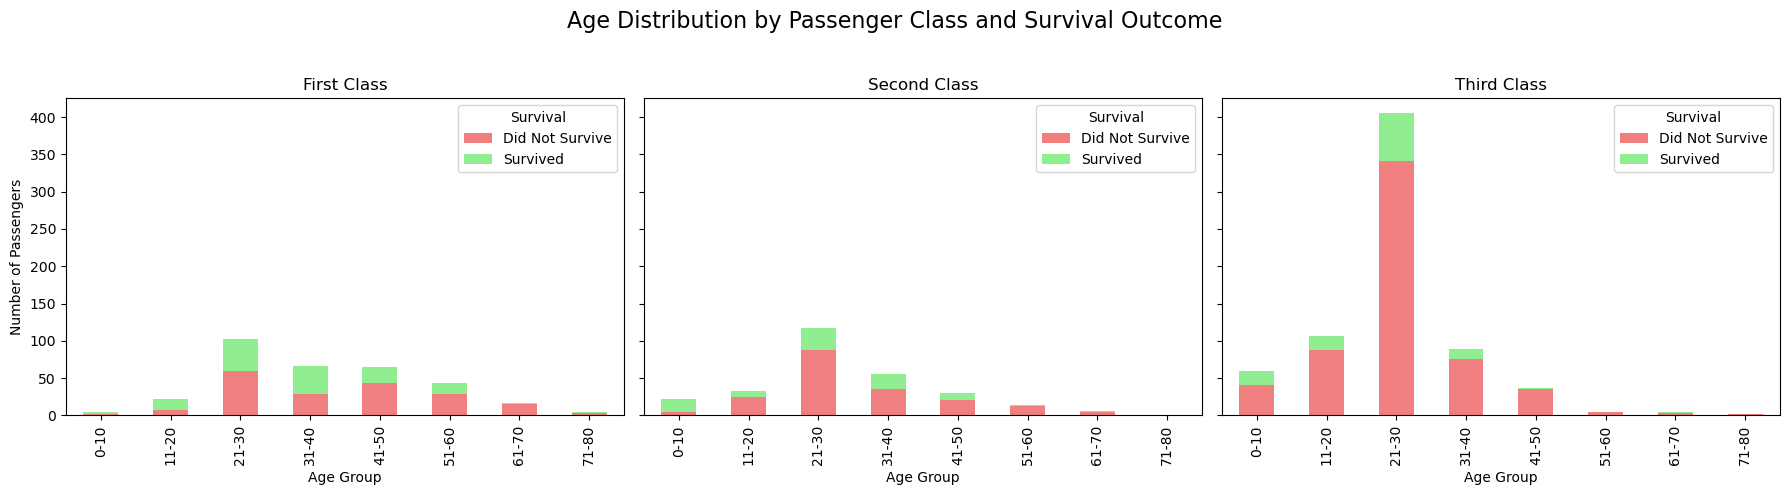

In [62]:
# Prepare data
data_temp = data.copy()
data_temp["Pclass_Label"] = data_temp["Pclass"].map({1: "First Class", 2: "Second Class", 3: "Third Class"})
data_temp["Survival_Label"] = data_temp["Survived"].map({0: "Did Not Survive", 1: "Survived"})

# Create age bins
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["0-10","11-20","21-30","31-40","41-50","51-60","61-70","71-80"]
data_temp["Age_Bin"] = pd.cut(data_temp["Age"], bins=age_bins, labels=age_labels, include_lowest=True)

# Prepare plot
classes = ["First Class", "Second Class", "Third Class"]
survival_status = ["Did Not Survive", "Survived"]
colors = {"Did Not Survive": "lightcoral", "Survived": "lightgreen"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, cls in enumerate(classes):
    ax = axes[i]
    subset = data_temp[data_temp["Pclass_Label"] == cls]
    counts = subset.groupby(["Age_Bin", "Survival_Label"], observed=False)["PassengerId"].count().unstack(fill_value=0)
    counts.plot(kind="bar", stacked=True, color=[colors[col] for col in counts.columns], ax=ax)
    ax.set_title(cls)
    ax.set_xlabel("Age Group")
    if i == 0:
        ax.set_ylabel("Number of Passengers")
    ax.legend(title="Survival", loc="upper right")

fig.suptitle("Age Distribution by Passenger Class and Survival Outcome", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


***Key Insight on Distribution of Passenger Ages with Mean & Std***: 

- A std of 12.9 is moderate to high relative to the mean. This indicates that passenger ages are fairly spread out - there are children, adults, and elderly passengers, not just a narrow age group.
- The min = 0.17 and max = 80 also shows wide age range (babies to elderly).

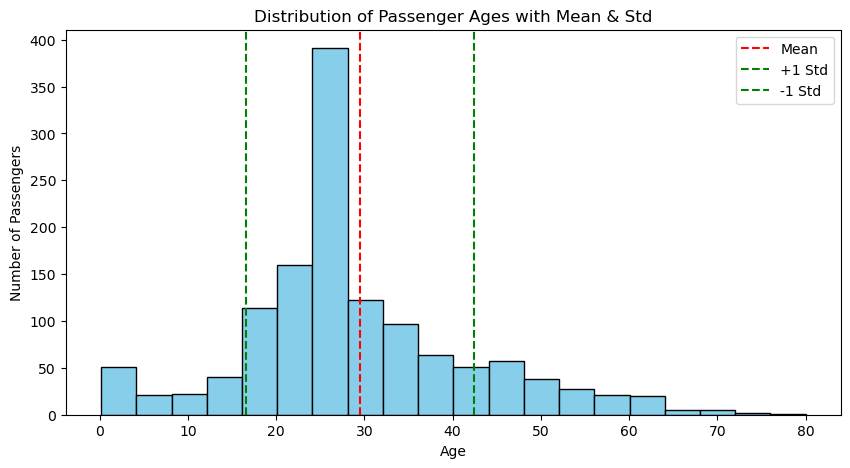

In [106]:
plt.figure(figsize=(10,5))
plt.hist(data["Age"].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.axvline(data["Age"].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(data["Age"].mean() + data["Age"].std(), color='green', linestyle='--', label='+1 Std')
plt.axvline(data["Age"].mean() - data["Age"].std(), color='green', linestyle='--', label='-1 Std')
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passenger Ages with Mean & Std")
plt.legend()
plt.show()

#### 3.4 Survival by Family size

Family size is explored using the number of siblings/spouses (`SibSp`) and parents/children (`Parch`).

***Insight***: 
- Passengers traveling alone or with very large families had lower survival rates.
- Small families (2-4 members) show higher survival likelihood.
- Family size is a meaningful behavioral feature.

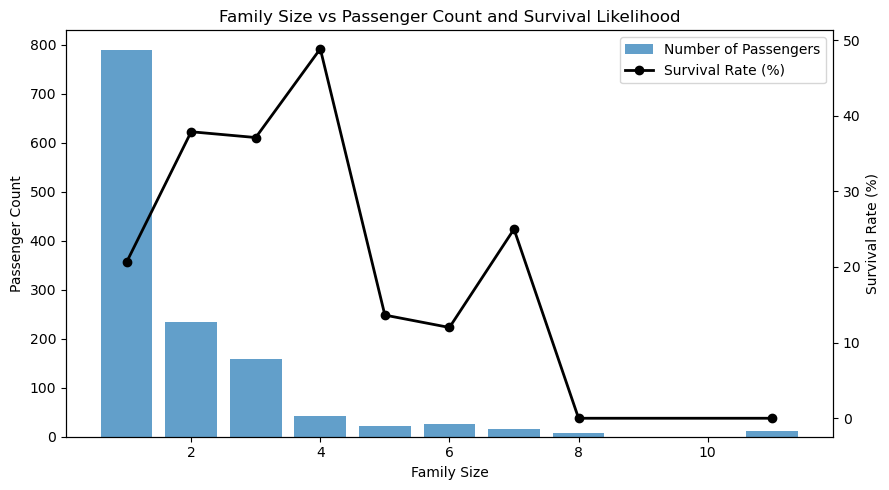

In [74]:
# Prepare data
family_stats = (
    data_viz
    .groupby("Family_Size")["Survived"]
    .agg(["count", "mean"])
)

family_stats["Survival_Rate"] = family_stats["mean"] * 100

# Create figure
fig, ax1 = plt.subplots(figsize=(9,5))

# Bar chart: passenger count
bars = ax1.bar(
    family_stats.index,
    family_stats["count"],
    alpha=0.7,
    label="Number of Passengers"
)
ax1.set_xlabel("Family Size")
ax1.set_ylabel("Passenger Count")

# Line chart: survival rate
ax2 = ax1.twinx()
line = ax2.plot(
    family_stats.index,
    family_stats["Survival_Rate"],
    marker="o",
    linewidth=2,
    color="black",
    label="Survival Rate (%)"
)
ax2.set_ylabel("Survival Rate (%)")

# Combine legends from both axes
handles = bars, line[0]
labels = ["Number of Passengers", "Survival Rate (%)"]
ax1.legend(handles, labels, loc="upper right")

# Title
plt.title("Family Size vs Passenger Count and Survival Likelihood")
plt.tight_layout()
plt.show()



#### 3.5 Family Relationships Analysis

We analyze how family relationships affected survival by combining the number of siblings/spouses (`SibSp`) and parents/children (`Parch`) aboard to form a `Family_Size` variable.  

A stacked bar chart shows the number of passengers in each family size category and whether they survived or not.

***Insight***: 
- Passengers with small families (1-3 members) had higher survival chances.
- Solo passengers (Family_Size = 0) and very large families had lower survival.

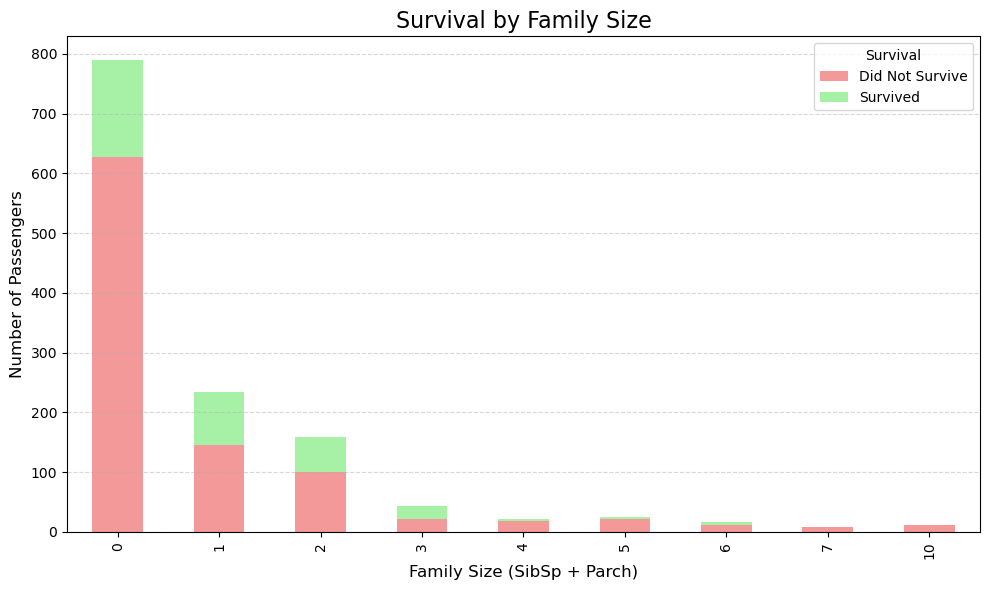

In [105]:
# Prepare data
data_viz = data.copy()
data_viz["Family_Size"] = data_viz["SibSp"] + data_viz["Parch"]  # Total family members aboard
data_viz["Survival_Label"] = data_viz["Survived"].map({0: "Did Not Survive", 1: "Survived"})

# Group data by family size and survival
family_counts = data_viz.groupby(["Family_Size", "Survival_Label"])["PassengerId"].count().unstack(fill_value=0)

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10,6))
family_counts.plot(kind="bar", stacked=True, color=["lightcoral", "lightgreen"], alpha=0.8, ax=ax)

# Titles and labels
ax.set_title("Survival by Family Size", fontsize=16)
ax.set_xlabel("Family Size (SibSp + Parch)", fontsize=12)
ax.set_ylabel("Number of Passengers", fontsize=12)
ax.legend(title="Survival", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


#### 3.6 Survival Rate Across Fare Categories

Passengers paid different fares, which likely reflect their socio-economic status. To analyze survival trends across fare levels, I categorize fares into four brackets:

- **Low Fare**: Passengers who paid the least
- **Medium Fare**: Passengers who paid slightly more
- **High Fare**: Passengers who paid considerably more
- **Very High Fare**: Passengers who paid the most (including outliers)

I then calculate the survival rate for each fare categories and visualize it.  

**Insights:**
- Higher-paying passengers had nearly 3x better survival chances than the lowest-paying group, indicating ticket price directly reflected access to safer locations and priority evacuation.
- Low fare passengers had lower survival rates, possibly reflecting limited access to lifeboats.
- Fare is highly skewed with strong outliers, so categorizing into brackets makes trends easier to interpret.
- The pattern is remarkably linear and monotonic, suggesting fare is a reliable predictor of survival outcome with minimal noise.

In [35]:
# Compute fare quantiles
fare_quantiles = data["Fare"].quantile([0.25, 0.50, 0.75])

fare_quantiles

0.25     7.8958
0.50    14.4542
0.75    31.2750
Name: Fare, dtype: float64

Based on the dataset:
- **Low Fare** passengers paid approximately ≤ 7.90
- **Medium Fare** passengers paid between 7.90 and 14.45
- **High Fare** passengers paid between 14.45 and 31.28
- **Very High Fare** passengers paid more than 31.28

This categorization allows clearer comparison of survival outcomes across socio-economic groups.


In [38]:
# Define fare bands with clear numeric meaning
data_viz = data.copy()

data_viz["Fare_Band"] = pd.cut(
    data_viz["Fare"],
    bins=[0, fare_quantiles[0.25], fare_quantiles[0.50], fare_quantiles[0.75], data["Fare"].max()],
    labels=["Low Fare", "Medium Fare", "High Fare", "Very High Fare"],
    include_lowest=True
)

print(data_viz[["Fare", "Fare_Band"]].head())


      Fare       Fare_Band
0   7.2500        Low Fare
1  71.2833  Very High Fare
2   7.9250     Medium Fare
3  53.1000  Very High Fare
4   8.0500     Medium Fare


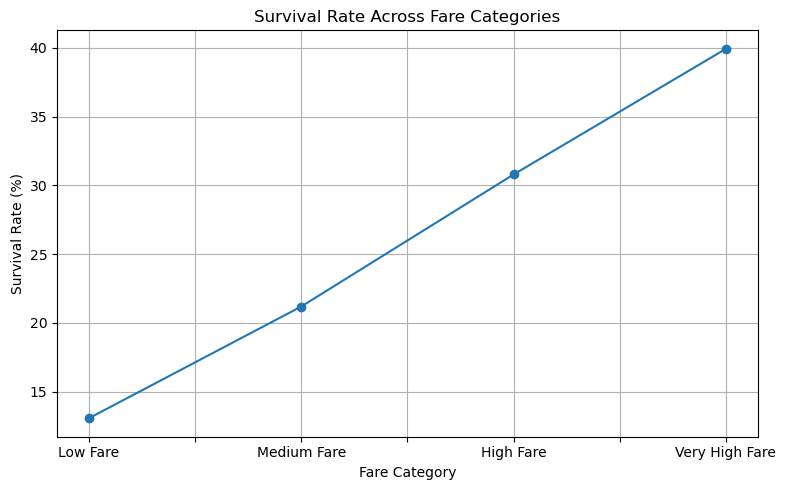

In [39]:
# Create fare bands using quantiles
data_viz = data.copy()
data_viz["Fare_Band"] = pd.qcut(
    data_viz["Fare"],
    q=4,
    labels=["Low Fare", "Medium Fare", "High Fare", "Very High Fare"]
)

# Survival rate per fare band
fare_survival = data_viz.groupby("Fare_Band", observed=True)["Survived"].mean() * 100

# Plot
plt.figure(figsize=(8,5))
fare_survival.plot(marker="o")

plt.xlabel("Fare Category")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate Across Fare Categories")
plt.grid(True)
plt.tight_layout()
plt.show()


### 4. Verify Data Quality

Before I move to data preparation, it is important to check if the dataset is clean and reliable. This step helps me identify missing values, outliers, duplicates, and data type related issues, so I can correct them if necessary.  

***This section entails the below steps***:

1. Normalize column names
2. Checking for missing values
2. Confirming correct data types
3. Detecting duplicate rows
4. Identifying outliers
5. Verifying consistency and valid ranges
6. Ensuring unique identifiers

#### Step 1: Normalize column names

In [90]:
# Step 1: Normalize column names
data = data.rename(columns={    
    "Passengerid": "PassengerId",
    "sibsp": "SibSp",
    "2urvived": "Survived",  # Fix spelling
    "parch": "Parch",
    "pclass": "Pclass",
    "fare": "Fare",
    "age": "Age"
})

# Step 1b: Filter out unnecessary columns starting with 'zero'
data = data[[col for col in data.columns if not col.lower().startswith("zero")]]

data.head()

,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


#### Step 2: Checking for missing values

In [91]:
# Missing values table
missing_summary = pd.DataFrame({
    "Missing Values Found": ["Yes" if data[col].isnull().sum() > 0 else "No" for col in data.columns],
    "Count": [data[col].isnull().sum() for col in data.columns]
}, index=data.columns)

missing_summary

,Missing Values Found,Count
PassengerId,No,0
Age,No,0
Fare,No,0
Sex,No,0
SibSp,No,0
Parch,No,0
Pclass,No,0
Embarked,Yes,2
Survived,No,0


#### Step 3: Confirming correct data types

In [92]:
# Data types
dtype_summary = pd.DataFrame({
    "Data Type": [data[col].dtype for col in data.columns]
}, index=data.columns)

dtype_summary

,Data Type
PassengerId,int64
Age,float64
Fare,float64
Sex,int64
SibSp,int64
Parch,int64
Pclass,int64
Embarked,float64
Survived,int64


#### Step 4: Detecting duplicate rows

In [95]:
# Find duplicate rows
duplicates = data.duplicated()
num_duplicates = duplicates.sum()
if num_duplicates > 0:
    print(f"Warning: Found {num_duplicates} duplicate rows in the dataset.")
else :
    print("No duplicate rows found in the dataset.")

No duplicate rows found in the dataset.


#### Step 5: Identifying outliers

In [108]:
# Numeric columns
numeric_cols = ["Age", "Fare", "Sex", "SibSp", "Parch", "Pclass", "Embarked", "Survived"]

# Outlier detection using IQR method
outlier_summary = []

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)][col].count()
    outlier_summary.append([col, "Yes" if outliers > 0 else "No", outliers])

outlier_summary_df = pd.DataFrame(outlier_summary, columns=["Column", "Outliers Found", "Count"])

outlier_summary_df

,Column,Outliers Found,Count
0,Age,Yes,101
1,Fare,Yes,171
2,Sex,No,0
3,SibSp,Yes,57
4,Parch,Yes,307
5,Pclass,No,0
6,Embarked,No,0
7,Survived,No,0


#### Step 6: Verifying consistency and valid ranges

In [102]:
# Define categorical columns
categorical_cols = ["Survived", "Pclass", "Sex", "Embarked"]

# Prepare summary rows
rows = []

for col in categorical_cols:
    col_dtype = data[col].dtype  # actual dtype
    for val, count in data[col].value_counts().items():
        rows.append({
            "Column": col,
            "Possible Value": str(val),
            "dtype": col_dtype,
            "Count": count
        })

# Convert to DataFrame
cat_summary_df = pd.DataFrame(rows)

# Sort by Column for readability
cat_summary_df = cat_summary_df.sort_values(by="Column").reset_index(drop=True)

cat_summary_df


,Column,Possible Value,dtype,Count
0,Embarked,2.0,float64,914
1,Embarked,0.0,float64,270
2,Embarked,1.0,float64,123
3,Pclass,3,int64,709
4,Pclass,1,int64,323
5,Pclass,2,int64,277
6,Sex,0,int64,843
7,Sex,1,int64,466
8,Survived,0,int64,967
9,Survived,1,int64,342


#### Step 7: Ensuring unique identifiers

In [104]:
# Step 7: Ensure PassengerId is Unique
unique_passenger_ids = data["PassengerId"].is_unique
if unique_passenger_ids:
    print("PassengerId is unique across all rows.")
else :
    print("Warning: PassengerId is not unique. Please check for duplicates.")

PassengerId is unique across all rows.


#### Step 8: Numeric Distribution and Outlier Detection

I use boxplots to visualize the distributions of numeric columns in the dataset. Each box shows:

- **Median (line inside the box)** – the middle value of the data.
- **Interquartile Range (IQR, box edges)** – the middle 50% of the data.
- **Whiskers** – typically 1.5 times the IQR, representing the expected range.
- **Outliers (points outside whiskers)** – extreme values that are unusually high or low.

**Insights:**
- `Age`: Some passengers are much older or younger than the majority (outliers present).
- `SibSp` & `Parch`: Most passengers travel alone or with 1–2 family members; a few have large families.
- `Fare`: Highly skewed with a few very high fares indicating wealthier passengers.


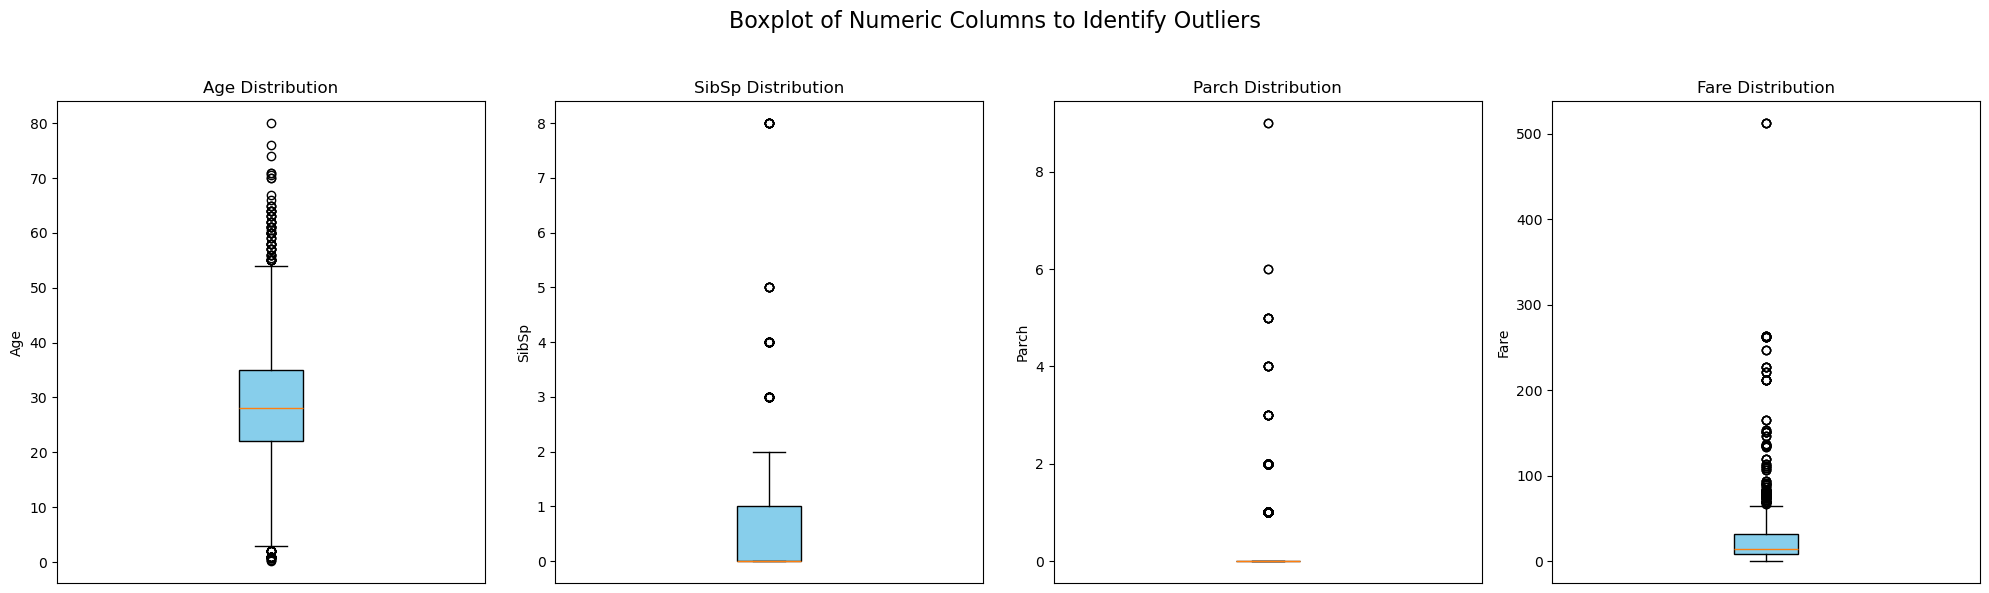

In [89]:
# Step 8: Visualize numeric distributions using Boxplots
numeric_cols = ["Age", "SibSp", "Parch", "Fare"]

# Set up figure
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna(), patch_artist=True, boxprops=dict(facecolor="skyblue"))
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel(col)
    axes[i].set_xticks([])  # Remove x-axis tick for clarity

plt.suptitle("Boxplot of Numeric Columns to Identify Outliers", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Conclusion
Outliers were identified in numeric features such as Age, Fare and Family Size. These values were not removed because they represent valid historical observations (e.g., wealthy first-class passengers). Instead of deleting them, feature engineering techniques such as fare categorization were applied to reduce skew while preserving meaningful information.